[2026-07-02 14:05:29] [info     ] 计算因子，测试区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-02 14:05:29] [info     ] GP 因子构建                        formula="rank(sub(col('rev_growth_20'), col('amihud_1')))" test_end='2024-12-31 23:59:59' test_start='2024-01-01 00:00:00' train_end='2023-03-31 23:59:59' train_start='2023-01-01 00:00:00'
[2026-07-02 14:05:29] [info     ] build_factor_panel 开始          end='2024-12-31 23:59:59' start='2024-01-01 00:00:00'
[2026-07-02 14:05:32] [info     ] 财务字段完成                         elapsed=2.37 rows=2491208
[2026-07-02 14:05:34] [info     ] 量价字段完成                         elapsed=2.39 rows=657209
[2026-07-02 14:05:37] [info     ] build_factor_panel 结束          elapsed=7.52 rows=526680
[2026-07-02 14:05:38] [info     ] 因子构建完成                         rows=242000
[2026-07-02 14:05:38] [info     ] 读取因子库，区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-02 14:05:38] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for pro

时段,IC
2024-01-15~2024-02-08,0.0087
2024-09-24~2024-10-08,0.0148

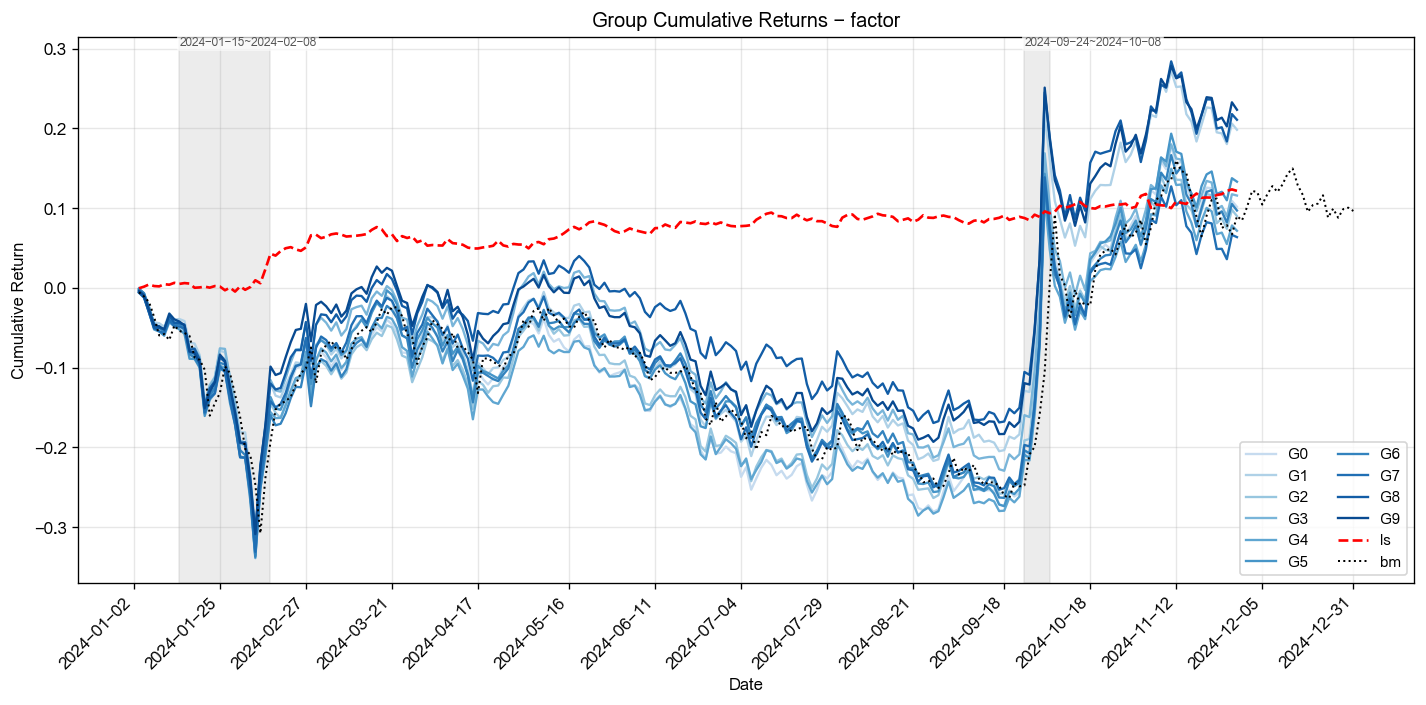
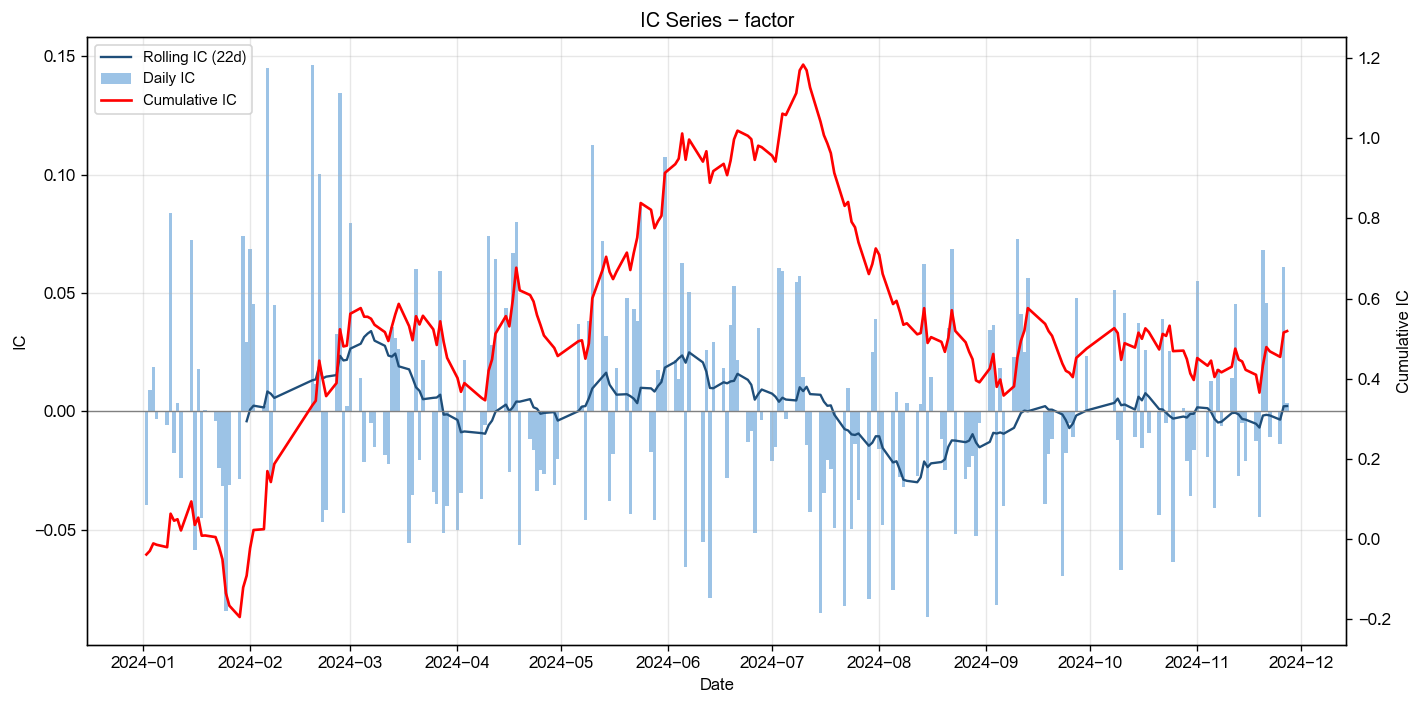
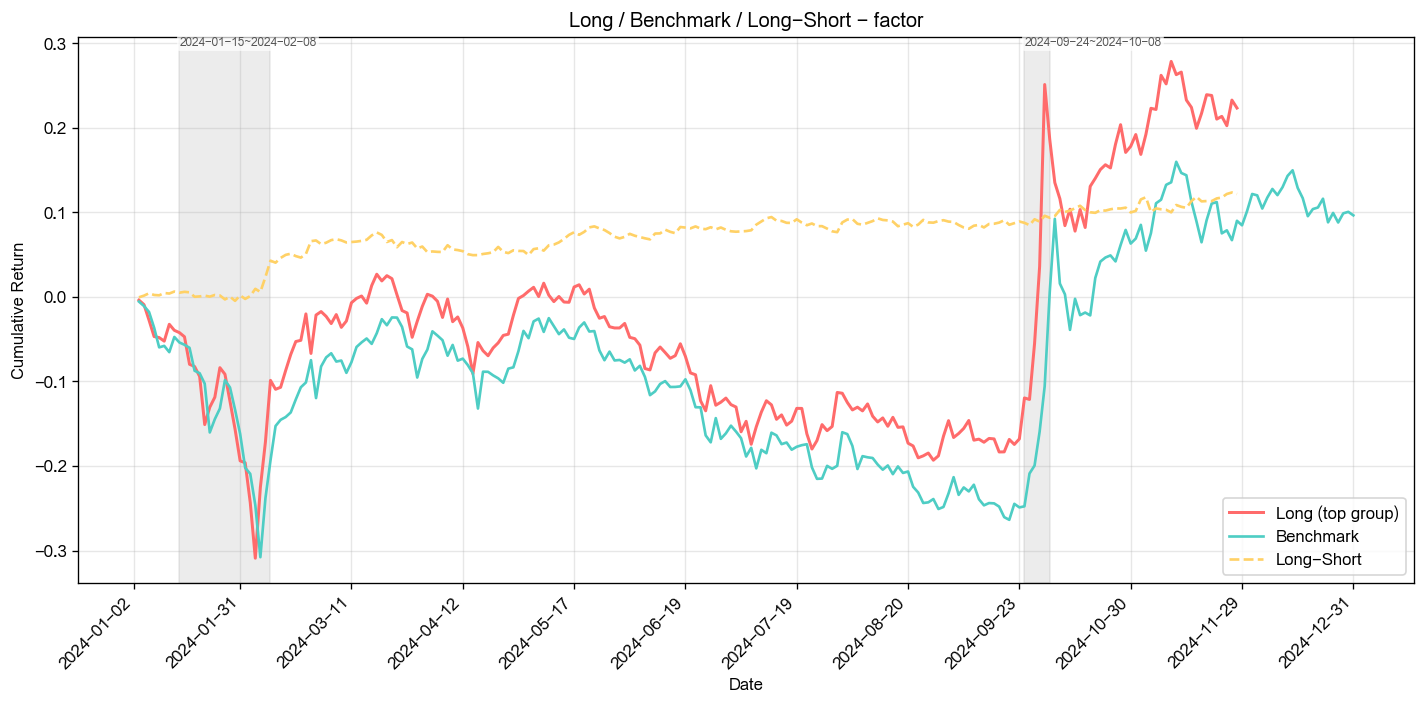
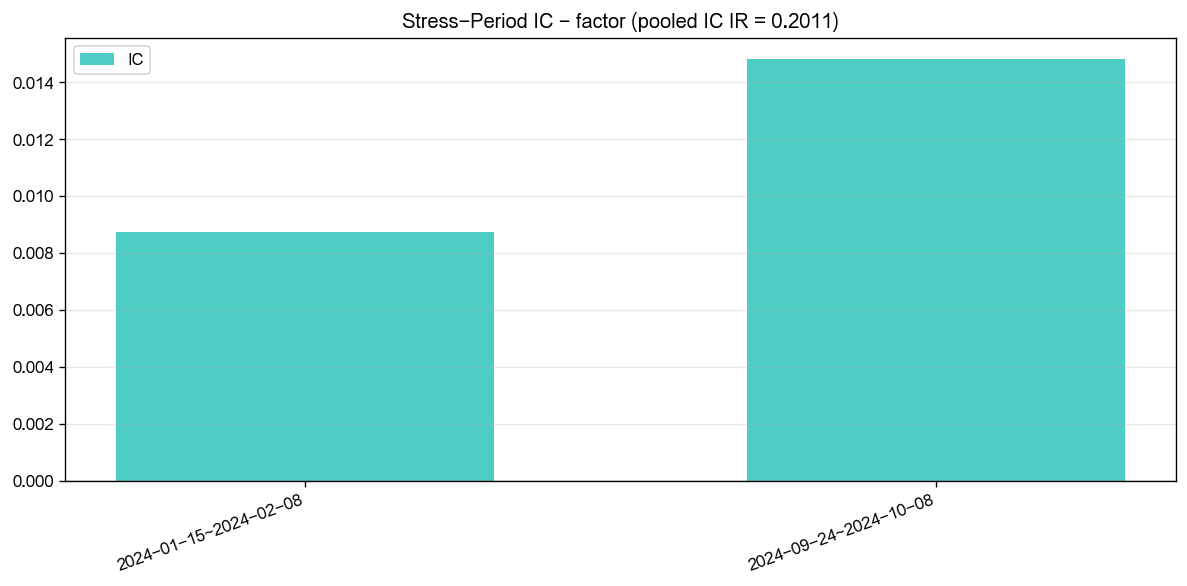
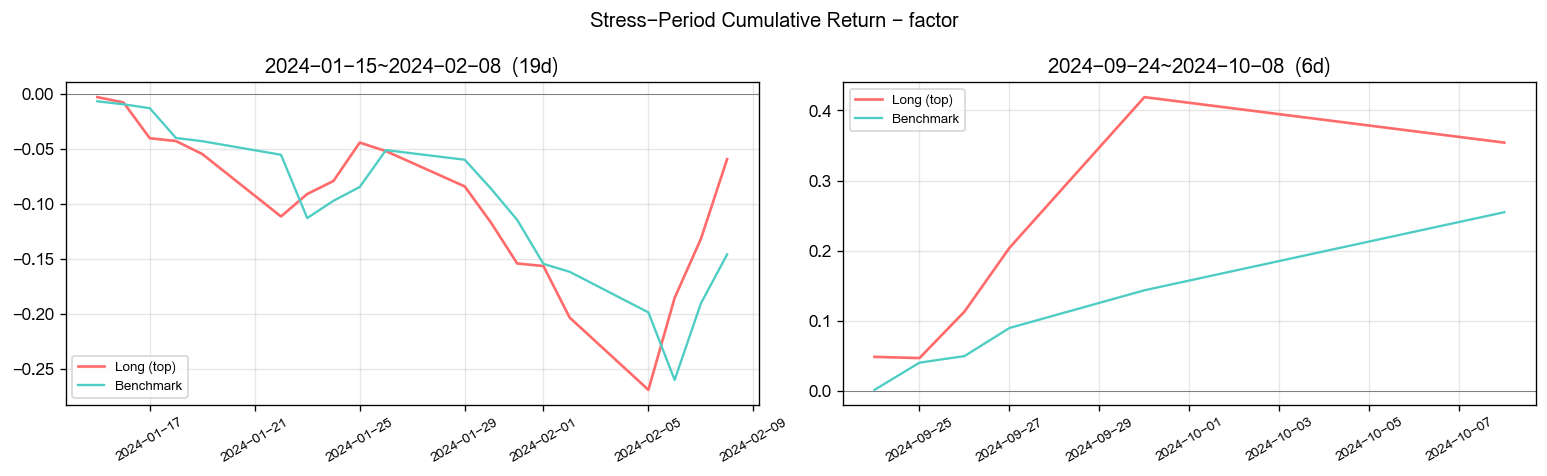

[2026-07-02 14:05:51] [info     ] ========== 因子池回归 ==========
[2026-07-02 14:05:52] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-07-02 14:05:54] [info     ] 获取收益率数据, 耗时: 2.5653 秒
[2026-07-02 14:05:55] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.9871 秒
[2026-07-02 14:05:55] [info     ] 统计 回归结果, 耗时: 0.0093 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,1.9065,0.0445,0.0233,1.0000
2,amount,1.7633,0.0187,0.0106,1.0000
3,netflow_amount_rate_main,1.5384,0.0099,0.0065,1.0000
4,netflow_amount_main,1.5145,0.0252,0.0167,1.0000
5,net_profit_rate_ttm,1.4870,0.0039,0.0026,0.8000
6,gross_profit_rate_ttm,1.4827,0.0070,0.0047,1.0000
7,pb,1.4509,0.0098,0.0067,1.0000
8,bias_20,1.4186,0.0292,0.0206,0.9000
9,cci_14,1.3757,0.0337,0.0245,1.0000
10,ps_ttm,1.3122,0.0037,0.0028,0.9000

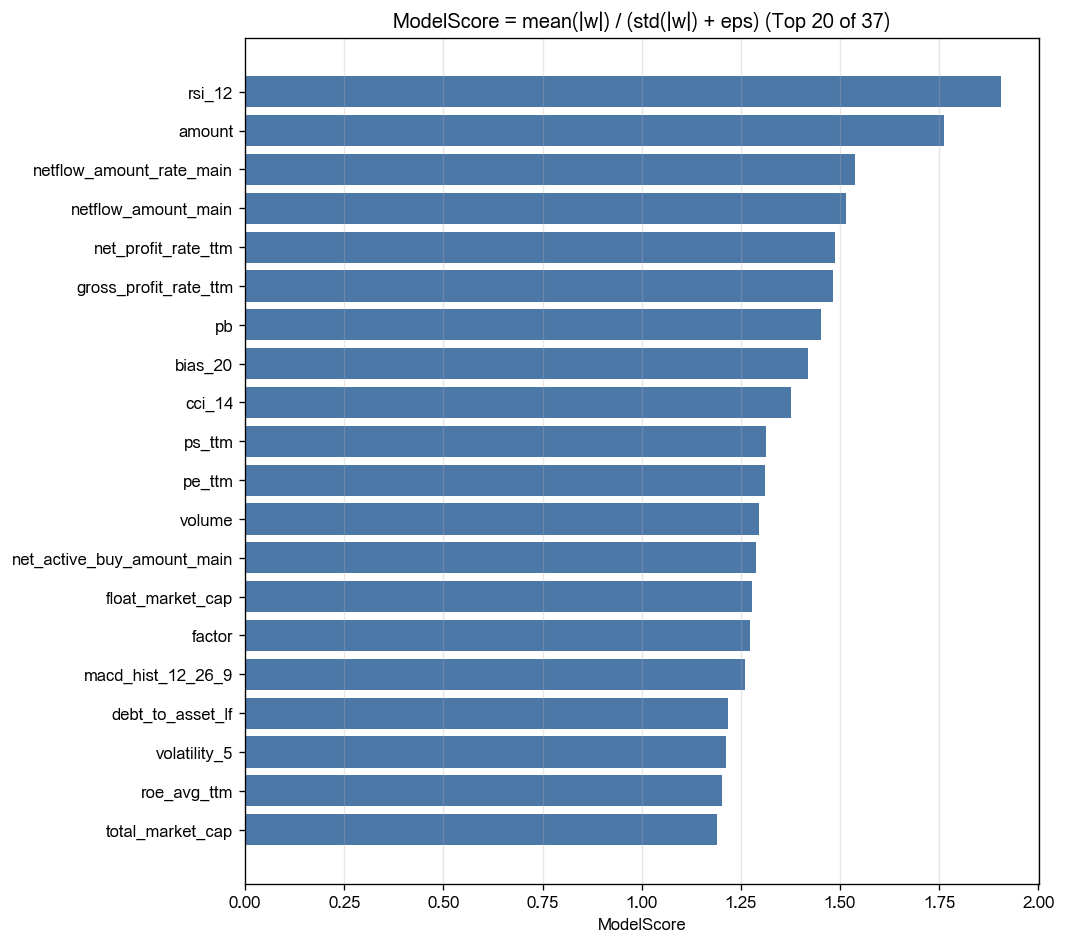
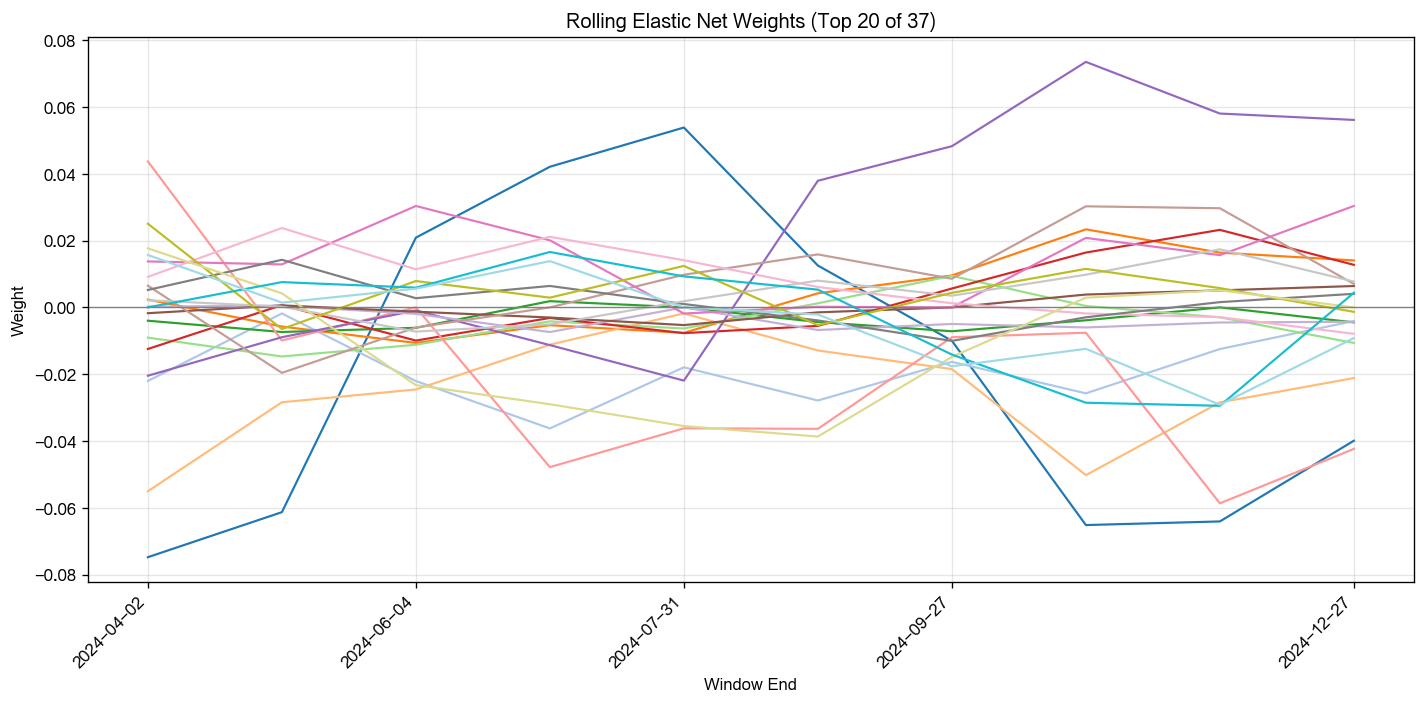
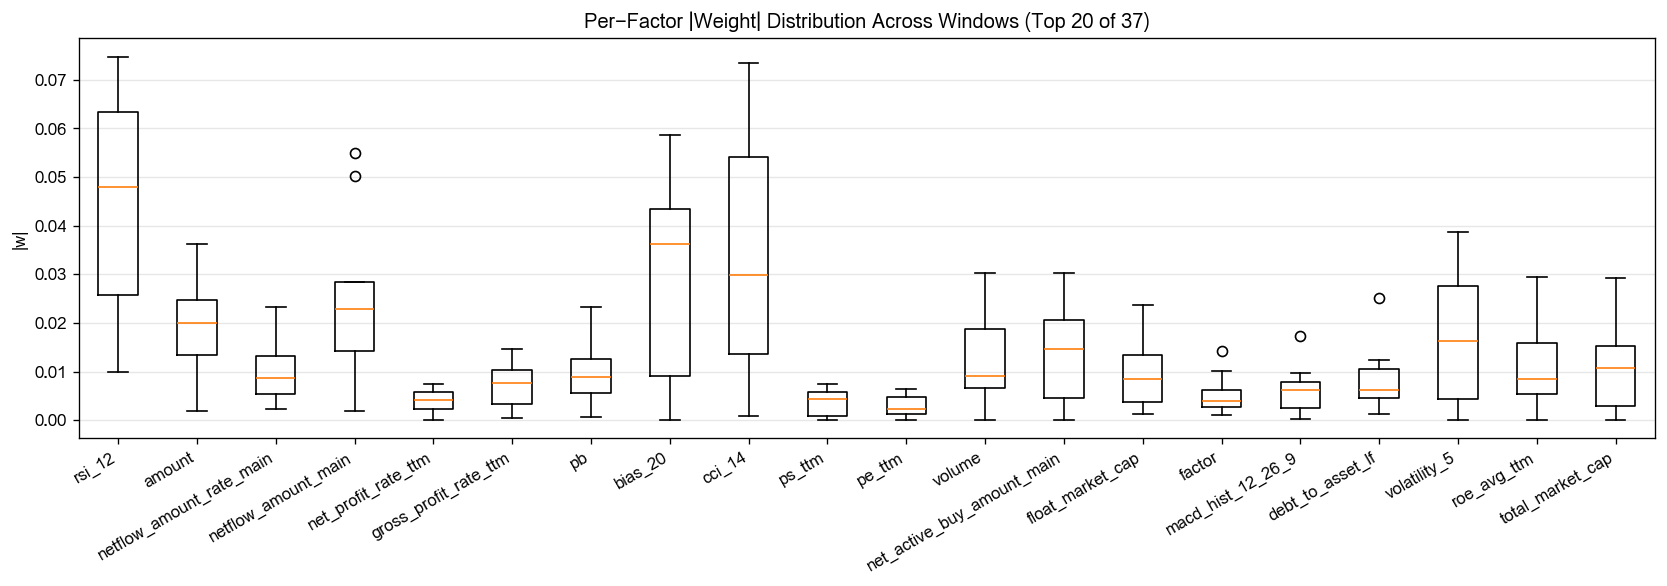
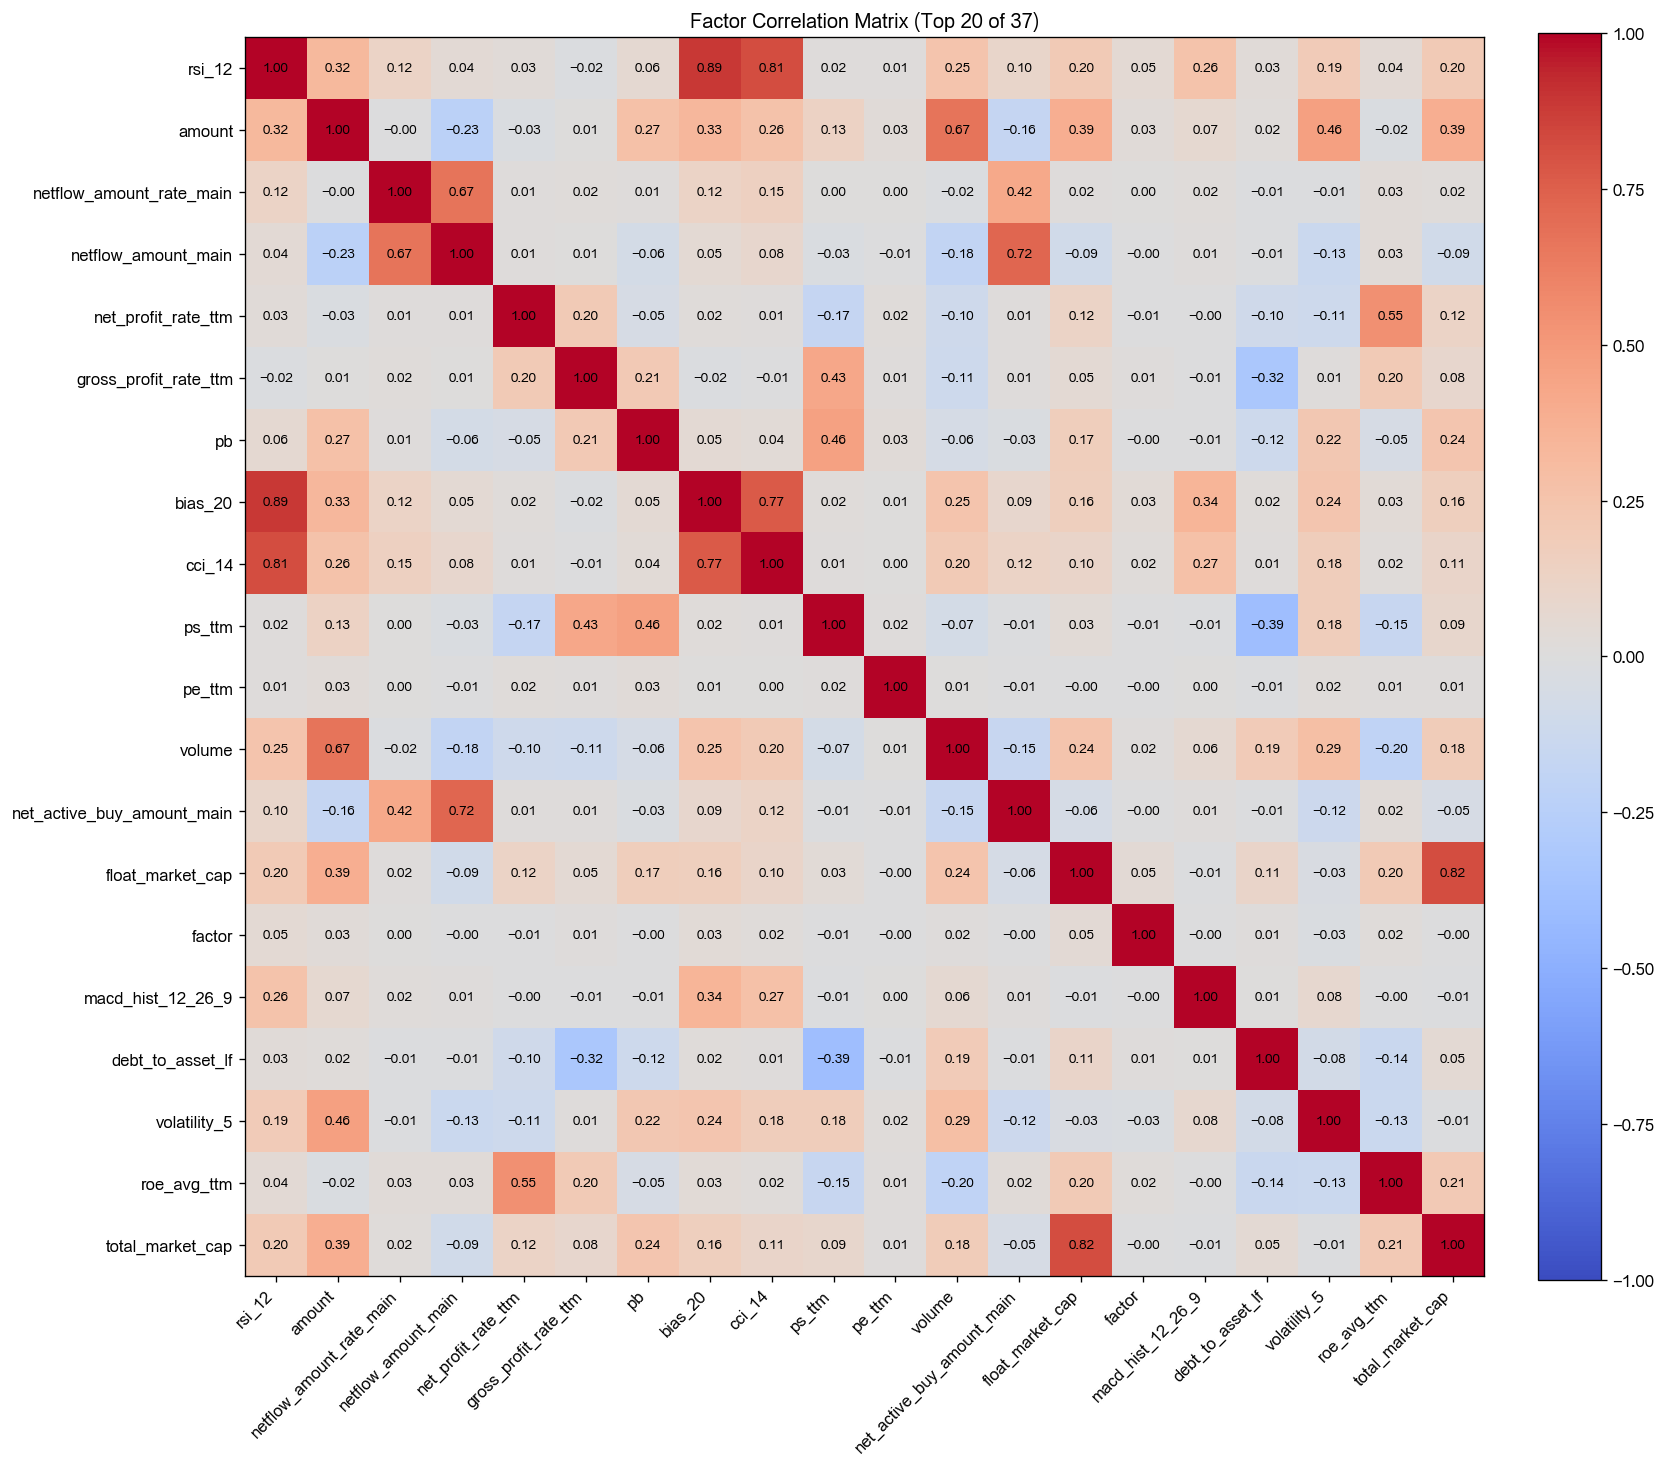

[2026-07-02 14:05:57] [warning  ] 返回的Outputs实例(size=33537174) 大于 64K, 将不会被缓存
[2026-07-02 14:05:57] [info     ] bigalpha_eval.v4 运行完成 [16.406s].


In [1]:
# 2023Q1 seed 最优；amihud 组合降低与 factorlib 成长/估值列共线（避免风格剔除后 NaN）
BEST_FORMULA = "rank(sub(col('rev_growth_20'), col('amihud_1')))"

FIN_LOOKBACK_DAYS = 730
PRICE_LOOKBACK_DAYS = 90
REV_GROWTH_LAG = 60  # ffill 财报序列上 ~一季交易日差分
FACTOR_FFILL_LIMIT = 20
NEUTRAL_RANK = 0.5

def build_factor_panel(
    financial_table: str,
    bar1m_table: str,
    sd: str,
    ed: str,
    logger: object | None = None,
) -> object:
    """量价日频 + 财务 ffill + 日历特征（含 rev_growth_20）。"""
    import time

    import dai
    import numpy as np
    import pandas as pd

    price_cols = ['open', 'high', 'low', 'close', 'volume', 'amount']
    fin_cols = [
        'operating_revenue',
        'net_profit_to_parent_shareholders',
        'total_assets',
        'total_equity_to_parent_shareholders',
    ]

    t0 = time.time()
    if logger is not None:
        logger.info('build_factor_panel 开始', start=str(sd), end=str(ed))

    fin_start = pd.to_datetime(sd) - pd.Timedelta(days=FIN_LOOKBACK_DAYS)
    fin_sql = f"""
    SELECT date, instrument, {', '.join(fin_cols)}
    FROM {financial_table}
    WHERE category='lf' AND shift=0
    """
    fin = dai.query(fin_sql, filters={'date': [fin_start, ed]}).df()

    def fill_natural_dates(df: pd.DataFrame, fill_sd: str, fill_ed: str) -> pd.DataFrame:
        natural_dates = pd.date_range(start=fill_sd, end=fill_ed)
        df = df.set_index('date')

        def reindex_and_fill(group_df: pd.DataFrame) -> pd.DataFrame:
            filled_df = group_df.reindex(natural_dates).ffill()
            filled_df['instrument'] = group_df.name
            return filled_df

        df_filled = df.groupby('instrument', group_keys=False).apply(reindex_and_fill)
        return (
            df_filled.reset_index()
            .rename(columns={'index': 'date'})
            .dropna(subset=['instrument'])
        )

    fin = fill_natural_dates(fin, fin_start, ed)
    fin['date'] = pd.to_datetime(fin['date'])
    if logger is not None:
        logger.info('财务字段完成', rows=len(fin), elapsed=round(time.time() - t0, 2))

    t1 = time.time()
    price_start = pd.to_datetime(sd) - pd.Timedelta(days=PRICE_LOOKBACK_DAYS)
    price_sql = f"""
    SELECT
        date_trunc('day', date)::DATE           AS trading_day,
        instrument,
        ARG_MIN(open, date)                     AS open,
        MAX(high)                               AS high,
        MIN(low)                                AS low,
        ARG_MAX(close, date)                    AS close,
        SUM(volume)                             AS volume,
        SUM(amount)                             AS amount
    FROM {bar1m_table}
    GROUP BY trading_day, instrument
    ORDER BY trading_day, instrument
    """
    price = dai.query(
        price_sql,
        filters={'date': [price_start, ed]},
        compression=True,
    ).df().rename(columns={'trading_day': 'date'})
    price['date'] = pd.to_datetime(price['date'])
    price = price.sort_values(['instrument', 'date']).reset_index(drop=True)
    if logger is not None:
        logger.info('量价字段完成', rows=len(price), elapsed=round(time.time() - t1, 2))

    df = pd.merge(price, fin, how='left', on=['date', 'instrument'])
    for col in price_cols + fin_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].replace([np.inf, -np.inf], np.nan)
    for col in fin_cols:
        df[col] = df.groupby('instrument', group_keys=False)[col].ffill()

    df = add_calendar_features(df)
    out = df[(df['date'] >= pd.to_datetime(sd)) & (df['date'] <= pd.to_datetime(ed))]
    if logger is not None:
        logger.info('build_factor_panel 结束', rows=len(out), elapsed=round(time.time() - t0, 2))
    return out.reset_index(drop=True)


def add_calendar_features(df: object) -> object:
    """预计算 GP 公式所需列（提交版仅保留当前公式依赖）。"""
    import numpy as np
    import pandas as pd

    if not isinstance(df, pd.DataFrame):
        raise TypeError('df 必须是 DataFrame')

    out = df.sort_values(['instrument', 'date']).copy()
    inst_g = out.groupby('instrument', group_keys=False)
    ret_1 = inst_g['close'].pct_change(1)
    out['amihud_1'] = ret_1.abs() / out['amount'].replace(0, np.nan)
    out['amihud_1'] = out['amihud_1'].replace([np.inf, -np.inf], np.nan)
    out['amihud_1'] = inst_g['amihud_1'].ffill(limit=10)

    def _rev_growth_20(s: pd.Series) -> pd.Series:
        lag = s.shift(REV_GROWTH_LAG)
        denom = lag.abs().clip(lower=1e-8)
        return (s - lag) / denom

    out['rev_growth_20'] = inst_g['operating_revenue'].transform(_rev_growth_20)
    out['rev_growth_20'] = out['rev_growth_20'].replace([np.inf, -np.inf], np.nan)
    out['rev_growth_20'] = inst_g['rev_growth_20'].ffill()
    return out


def fill_factor_values(df: object) -> object:
    """对齐 stk_pool 后填充 factor，并保证每个交易日截面有方差（避免 eval 标准化变 NaN）。"""
    import numpy as np
    import pandas as pd

    if not isinstance(df, pd.DataFrame):
        raise TypeError('df 必须是 DataFrame')

    out = df.sort_values(['instrument', 'date']).copy()
    out['factor'] = pd.to_numeric(out['factor'], errors='coerce')
    out['factor'] = out.groupby('instrument')['factor'].ffill(limit=FACTOR_FFILL_LIMIT)
    out['factor'] = out.groupby('instrument')['factor'].bfill(limit=10)

    def _finalize_cs(x: pd.Series) -> pd.Series:
        import numpy as np

        s = x.copy()
        if s.notna().sum() == 0:
            n = len(s)
            return pd.Series(np.linspace(0.01, 0.99, n), index=s.index, dtype=float)
        med = float(s.median())
        if med != med:
            med = NEUTRAL_RANK
        s = s.fillna(med)
        if s.nunique() <= 1:
            n = len(s)
            return pd.Series(np.linspace(0.01, 0.99, n), index=s.index, dtype=float)
        return s.rank(pct=True, method='average')

    out['factor'] = out.groupby('date')['factor'].transform(_finalize_cs)
    return out


def eval_formula(df: object, expr: str) -> object:
    """在安全算子集上执行写死的 GP 公式。"""
    import numpy as np
    import pandas as pd

    if not isinstance(df, pd.DataFrame):
        raise TypeError('df 必须是 DataFrame')

    frame = df.sort_values(['instrument', 'date']).copy()
    inst_g = frame.groupby('instrument', group_keys=False)

    def col(name: str) -> pd.Series:
        if name not in frame.columns:
            raise ValueError(f'未知字段: {name}')
        return frame[name]

    def ts_pct(name: str, n: int) -> pd.Series:
        return inst_g[name].pct_change(int(n))

    def rank(x: pd.Series) -> pd.Series:
        s = pd.Series(x, index=frame.index, dtype=float)
        return s.groupby(frame['date']).rank(pct=True, method='average')

    def add(a: pd.Series, b: pd.Series) -> pd.Series:
        return a + b

    def sub(a: pd.Series, b: pd.Series) -> pd.Series:
        return a - b

    def mul(a: pd.Series, b: pd.Series) -> pd.Series:
        return a * b

    def div(a: pd.Series, b: pd.Series) -> pd.Series:
        return a / b.replace(0, np.nan)

    def neg(x: pd.Series) -> pd.Series:
        return -x

    safe_globals: dict[str, object] = {'__builtins__': {}}
    safe_locals: dict[str, object] = {
        'col': col,
        'ts_pct': ts_pct,
        'rank': rank,
        'add': add,
        'sub': sub,
        'mul': mul,
        'div': div,
        'neg': neg,
    }
    out = eval(expr, safe_globals, safe_locals)
    factor = pd.Series(out, index=frame.index, dtype=float)
    return factor.replace([np.inf, -np.inf], np.nan)


def main(datasources: dict[str, str], start_date: str, end_date: str) -> object:
    """
    BigAlpha 2026 GP 因子（提交版）

    因子逻辑:
        rev_growth_20 = 营收 ~60 交易日差分增速（财务 PIT + 日频 ffill）
        amihud_1 = |ret|/amount 流动性
        factor = rank(rev_growth_20 - amihud_1)，降低与 factorlib 成长/估值共线

    赛制约定:
        start_date / end_date 为【测试集】区间，仅用于样本外计算因子。
        GP 公式已在训练期离线选定并写死为 BEST_FORMULA，main 内不做进化。

    返回:
        pd.DataFrame: ['date', 'instrument', 'factor']，无 inf
    """
    import dai
    import numpy as np
    import pandas as pd
    import structlog

    logger = structlog.get_logger()
    train_start = '2023-01-01 00:00:00'
    train_end = '2023-03-31 23:59:59'

    logger.info(
        'GP 因子构建',
        formula=BEST_FORMULA,
        train_start=train_start,
        train_end=train_end,
        test_start=start_date,
        test_end=end_date,
    )

    bar1m_table = datasources['bar1m']
    financial_table = datasources['financial']
    panel = build_factor_panel(financial_table, bar1m_table, start_date, end_date, logger)
    panel['factor'] = eval_formula(panel, BEST_FORMULA)
    panel['factor'] = panel.groupby('instrument')['factor'].transform(
        lambda s: s.rolling(5, min_periods=1).mean()
    )

    stk_pool = dai.query(
        'SELECT date, instrument FROM bigalpha_2026_instruments',
        filters={'date': [start_date, end_date]},
        compression=True,
    ).df()
    stk_pool['date'] = pd.to_datetime(stk_pool['date'])
    stk_pool['instrument'] = stk_pool['instrument'].astype(str)
    panel['date'] = pd.to_datetime(panel['date'])
    panel['instrument'] = panel['instrument'].astype(str)

    result = pd.merge(
        stk_pool,
        panel[['date', 'instrument', 'factor']],
        how='left',
        on=['date', 'instrument'],
    )
    result['factor'] = result['factor'].replace([np.inf, -np.inf], np.nan)
    result = fill_factor_values(result)
    result = result[['date', 'instrument', 'factor']].reset_index(drop=True)

    logger.info('因子构建完成', rows=len(result))
    return result


if __name__ == '__main__':
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    # 本地自测时自行构造数据源映射（评测时由平台注入，逻辑名固定为 "bar1m"/"financial"）
    datasources = {
        'bar1m': 'bigalpha_2026_stock_bar1m',
        'financial': 'bigalpha_2026_financial',
    }
    # 本地用这段区间模拟「平台注入的测试集区间」（训练区间已在 main 内写死）
    start_date = '2024-01-01 00:00:00'
    end_date = '2024-12-31 23:59:59'

    # 计算因子
    logger.info(f"计算因子，测试区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    # 读取平台因子库用于回归评估，您可以换成自己的因子库
    logger.info(f"读取因子库，区间：{start_date} ~ {end_date}")
    factor_pool = dai.query(
        'SELECT * FROM bigalpha_2026_factorlib',
        filters={'date': [start_date, end_date]},
    ).df()

    # 评估系统：
    # process_pools=False 表示不对因子库再做预处理（bigalpha_2026_factorlib 已处理过）
    # show=True 表示画出评估图表
    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
        start_date=start_date,
        end_date=end_date,
    )
